In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/liver-cirrhosis-stage-detection-dataset/liver_cirrhosis.csv


# 🧠 Liver Cirrhosis Stage Detection
**Author**: Sushree Bandita Das  
**Role**: Machine Learning Intern @ Elevate Labs  
**Objective**: Predict liver cirrhosis stage using clinical data  

In [3]:

df = pd.read_csv('/kaggle/input/liver-cirrhosis-stage-detection-dataset/liver_cirrhosis.csv')
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [4]:
df.isnull().sum()
df.dtypes

N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage              int64
dtype: object

In [5]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [6]:
from sklearn.preprocessing import StandardScaler

num_cols = ['N_Days','Age','Bilirubin','Cholesterol','Albumin','Copper',
            'Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  float64
 1   Status         25000 non-null  int64  
 2   Drug           25000 non-null  int64  
 3   Age            25000 non-null  float64
 4   Sex            25000 non-null  int64  
 5   Ascites        25000 non-null  int64  
 6   Hepatomegaly   25000 non-null  int64  
 7   Spiders        25000 non-null  int64  
 8   Edema          25000 non-null  int64  
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,2.500000e+04,25000.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.00000,25000.00000,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,2.500000e+04,25000.00000
mean,-7.844392e-17,0.837600,0.633080,4.320100e-16,0.114520,0.328080,0.390280,0.45544,0.23448,1.034550e-16,1.557510e-16,1.265335e-15,-7.162271e-17,-3.524292e-17,-9.407586e-17,4.862954e-16,5.331913e-16,1.192575e-15,2.00116
std,1.000020e+00,0.944744,0.481974,1.000020e+00,0.318448,0.469524,0.487823,0.49802,0.51582,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,0.81387
min,-1.691096e+00,0.000000,0.000000,-2.380689e+00,0.000000,0.000000,0.000000,0.00000,0.00000,-6.590998e-01,-1.302930e+00,-4.012235e+00,-1.314297e+00,-9.487594e-01,-2.027709e+00,-1.720603e+00,-1.966084e+00,-1.917863e+00,1.00000
25%,-7.393422e-01,0.000000,0.000000,-7.496617e-01,0.000000,0.000000,0.000000,0.00000,0.00000,-5.528840e-01,-5.025776e-01,-5.166579e-01,-6.584099e-01,-5.357177e-01,-6.527440e-01,-6.028677e-01,-6.790571e-01,-8.121788e-01,1.00000
50%,-1.897251e-01,0.000000,1.000000,8.355590e-04,0.000000,0.000000,0.000000,0.00000,0.00000,-4.466681e-01,-1.456595e-02,6.155790e-02,-3.465644e-02,-9.321268e-02,-1.277574e-02,1.666335e-02,-5.074471e-02,-1.487686e-01,2.00000
75%,6.310364e-01,2.000000,1.000000,6.579555e-01,0.000000,1.000000,1.000000,1.00000,0.00000,-5.616693e-04,-1.456595e-02,6.923388e-01,9.312685e-02,-7.237863e-03,2.447010e-01,6.019578e-02,5.572995e-01,4.040733e-01,3.00000
max,2.663704e+00,2.000000,1.000000,2.716806e+00,1.000000,1.000000,1.000000,1.00000,2.00000,5.225257e+00,7.242773e+00,3.031484e+00,6.665658e+00,6.596840e+00,6.997006e+00,8.983135e+00,4.712268e+00,8.033291e+00,3.00000


Distribution of Cirrrhosis Stages

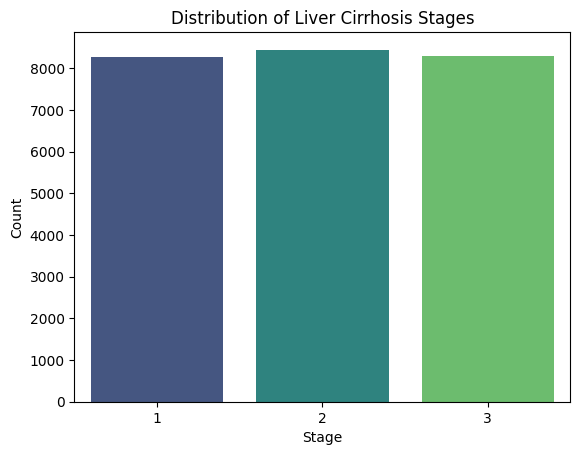

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot stage distribution
sns.countplot(x='Stage', data=df, palette='viridis')
plt.title('Distribution of Liver Cirrhosis Stages')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

Correlation Heatmap

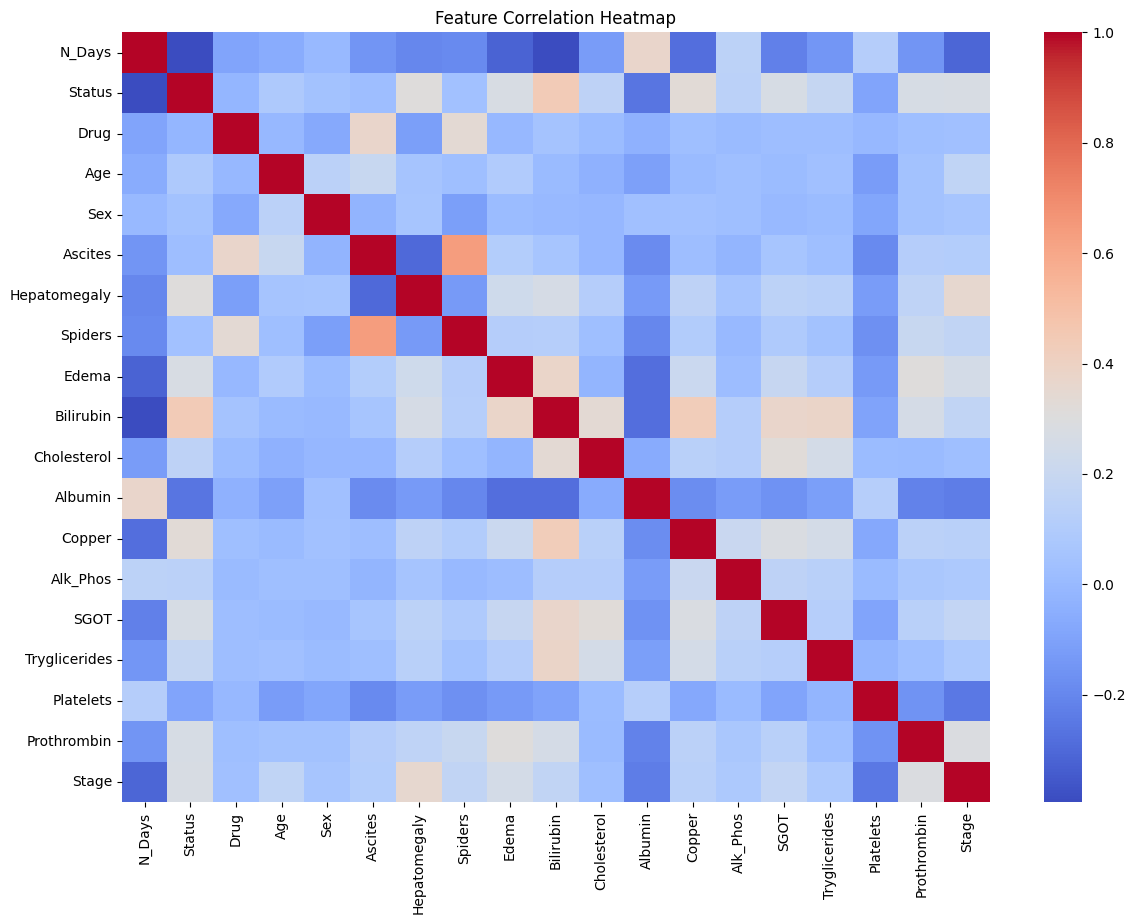

In [9]:
# Correlation matrix
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

Boxplot of Bilirubin by Stage

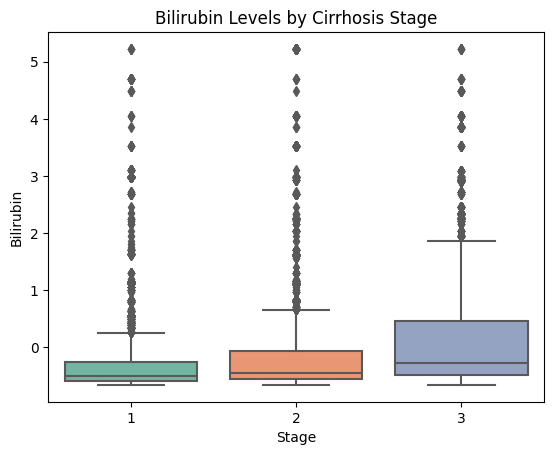

In [10]:
sns.boxplot(x='Stage', y='Bilirubin', data=df, palette='Set2')
plt.title('Bilirubin Levels by Cirrhosis Stage')
plt.show()

## 📊 Exploratory Data Analysis (EDA)
We explore how clinical features relate to liver cirrhosis stages.  
Visuals include:
- Stage distribution
- Feature correlations
- Bilirubin variation across stages

Train a Classification Mode ( Random Forest )

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Stage', axis=1)
y = df['Stage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9556

Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.94      0.95      1657
           2       0.94      0.96      0.95      1697
           3       0.96      0.97      0.97      1646

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000


Confusion Matrix:
 [[1556   76   25]
 [  35 1625   37]
 [  16   33 1597]]


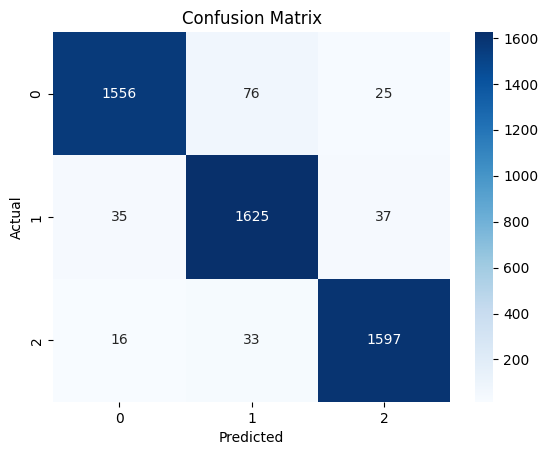

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 🏗️ Model Training & Evaluation
We trained a Random Forest classifier to predict liver cirrhosis stage.  
Key metrics:
- Accuracy
- Precision, Recall, F1-score
- Confusion Matrix

## 🎯 Project Summary
This notebook demonstrates a complete ML pipeline for predicting liver cirrhosis stages using clinical data.  
Key highlights:
- Data cleaning, encoding, and normalization
- Exploratory visualizations (heatmaps, boxplots)
- Random Forest model with strong performance
- Confusion matrix and classification metrics

**Author**: Sushree Bandita Das  
**Portfolio**: [GitHub Profile](https://github.com/yourusername)  
**Role**: Machine Learning Intern @ Elevate Labs  